In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds
import sonnet as snt

print("TensorFlow version {}".format(tf.__version__))
print("Sonnet version {}".format(snt.__version__))

TensorFlow version 2.4.1
Sonnet version 2.0.0


In [5]:
batch_size = 100

def process_batch(images, labels):
  images = tf.squeeze(images, axis=[-1])
  images = tf.cast(images, dtype=tf.float32)
  images = ((images / 255.) - .5) * 2.
  return images, labels

def mnist(split):
  dataset = tfds.load("mnist", split=split, as_supervised=True)
  dataset = dataset.map(process_batch)
  dataset = dataset.batch(batch_size)
  dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
  dataset = dataset.cache()
  return dataset

mnist_train = mnist("train").shuffle(10)
mnist_test = mnist("test")

Dl Completed...: 100%|██████████| 4/4 [00:02<00:00,  1.60 file/s]
Dataset mnist downloaded and prepared to /home/claude/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.



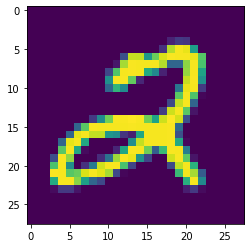

In [6]:
import matplotlib.pyplot as plt

images, _ = next(iter(mnist_test))
plt.imshow(images[0])

In [7]:
# Sonnet

class MLP(snt.Module):

  def __init__(self):
    super(MLP, self).__init__()
    self.flatten = snt.Flatten()
    self.hidden1 = snt.Linear(1024, name="hidden1")
    self.hidden2 = snt.Linear(1024, name="hidden2")
    self.logits = snt.Linear(10, name="logits")

  def __call__(self, images):
    output = self.flatten(images)
    output = tf.nn.relu(self.hidden1(output))
    output = tf.nn.relu(self.hidden2(output))
    output = self.logits(output)
    return output

In [8]:
mlp = MLP()
mlp

MLP()

Predicted class: 3 actual class: 2


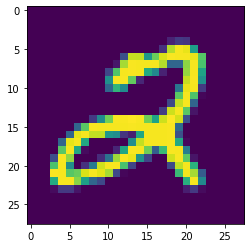

In [11]:
images, labels = next(iter(mnist_test))
logits = mlp(images)
prediction = tf.argmax(logits[0]).numpy()
actual = labels[0].numpy()
print("Predicted class: {} actual class: {}".format(prediction, actual))
plt.imshow(images[0])

To train the model we need an optimizer. For this simple example we'll use Stochastic Gradient Descent which is implemented in the SGD optimizer. To compute gradients we'll use a tf.GradientTape which allows us to selectively record gradients only for the computation we want to back propagate through:

In [16]:
from tqdm import tqdm
opt = snt.optimizers.SGD(learning_rate=0.1)
num_epochs = 10

def step(images, labels):
  """Performs one optimizer step on a single mini-batch."""
  with tf.GradientTape() as tape:
    logits = mlp(images)
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(logits=logits,
                                                          labels=labels)
    loss = tf.reduce_mean(loss)

  params = mlp.trainable_variables
  grads = tape.gradient(loss, params)
  opt.apply(grads, params)

for images, labels in tqdm(mnist_train.repeat(num_epochs)):
  loss = step(images, labels)

print("\n\nFinal loss: {}".format(loss.numpy()))

100%|██████████| 6000/6000 [01:45<00:00, 57.09it/s]


AttributeError: 'NoneType' object has no attribute 'numpy'

In [ ]:
# evaluate the model

total = 0
correct = 0
for images, labels in mnist_test:
  predictions = tf.argmax(mlp(images), axis=1)
  correct += tf.math.count_nonzero(tf.equal(predictions, labels))
  total += images.shape[0]

print("Got %d/%d (%.02f%%) correct" % (correct, total, correct / total * 100.))